In [18]:
import MetaTrader5 as mt5
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

sns.set_style("darkgrid")
warnings.filterwarnings("ignore")

In [19]:
if not mt5.initialize():
    print("Metratrader5 initialization failed, Error code =", mt5.last_error())
    mt5.shutdown()

### Getting data from MetaTrader 5

In [20]:
rates_nq = mt5.copy_rates_from_pos("NAS100", mt5.TIMEFRAME_D1, 1, 1000)
rates_df_nq = pd.DataFrame(rates_nq)

rates_snp = mt5.copy_rates_from_pos("US500", mt5.TIMEFRAME_D1, 1, 1000)
rates_df_snp = pd.DataFrame(rates_snp)

In [21]:
# NAS100
rates_df_nq["ds"] = pd.to_datetime(rates_df_nq["time"], unit="s")
rates_df_nq["y"] = rates_df_nq["close"]
rates_df_nq["unique_id"] = "NAS100"
df_nq = rates_df_nq[["unique_id", "ds", "y"]]

# US500
rates_df_snp["ds"] = pd.to_datetime(rates_df_snp["time"], unit="s")
rates_df_snp["y"] = rates_df_snp["close"]
rates_df_snp["unique_id"] = "US500"
df_snp = rates_df_snp[["unique_id", "ds", "y"]]

### Convert into one multi-series dataframe

In [22]:
multivariate_df = pd.concat([df_nq, df_snp], ignore_index=True) # combine both dataframes
multivariate_df = multivariate_df.sort_values(['unique_id', 'ds']).reset_index(drop=True) # sort by unique_id and date

multivariate_df

,unique_id,ds,y
0,NAS100,2021-09-01,15611.5
1,NAS100,2021-09-02,15599.3
2,NAS100,2021-09-03,15651.7
3,NAS100,2021-09-06,15700.4
4,NAS100,2021-09-07,15670.8
...,...,...,...
1995,US500,2025-07-09,6264.9
1996,US500,2025-07-10,6280.3
1997,US500,2025-07-11,6255.8
1998,US500,2025-07-14,6271.9


In [23]:
split_date = '2024-01-01'  # the split date for training and testing

train_df = multivariate_df[multivariate_df['ds'] < split_date] 
test_df = multivariate_df[multivariate_df['ds'] >= split_date]

In [24]:
train_df

,unique_id,ds,y
0,NAS100,2021-09-01,15611.5
1,NAS100,2021-09-02,15599.3
2,NAS100,2021-09-03,15651.7
3,NAS100,2021-09-06,15700.4
4,NAS100,2021-09-07,15670.8
...,...,...,...
1598,US500,2023-12-22,4752.0
1599,US500,2023-12-26,4782.4
1600,US500,2023-12-27,4789.5
1601,US500,2023-12-28,4788.4


### Train NBEAST Model

In [26]:
from neuralforecast import NeuralForecast 
from neuralforecast.models import NBEATS # Neural Basis Expansion Analysis for Time Series

# Define model and horizon
horizon = 30  # forecast 30 days into the future

model = NeuralForecast(
    models=[NBEATS(h=horizon, # predictive horizon of the model
                   input_size=90, # considered autorregresive inputs (lags), y=[1,2,3,4] input_size=2 -> lags=[1,2].
                   max_steps=100, # maximum number of training steps (epochs)
                   stack_types=['trend', 'seasonality'],  # ← key for interpretability
                   basis='polynomial', # basis function for the trend and seasonality stacks
                   n_blocks=[2,2], # number of blocks in each stack, e.g. [2,2] means 2 blocks for each stack type
                   n_basis=4, # number of basis functions for the trend and seasonality stacks
                   shared_weights=False,
                   scaler_type='robust', # scaler type for the time series data
                   )], 
    freq='D' # frequency of the time series data
)

# Fit the model
model.fit(df=train_df)

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 3.5 M  | train
-------------------------------------------------------
3.5 M     Trainable params
15.1 K    Non-trainable params
3.5 M     Total params
13.931    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


In [27]:
test_forecast = model.predict() # predict future 30 days based on the training data

df_test = pd.merge(test_df, test_forecast, on=['ds', 'unique_id'], how='outer') # merge the test data with the forecast
df_test.dropna(inplace=True) # drop rows with NaN values

df_test

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,y,NBEATS
6,NAS100,2024-01-02,16554.3,16261.056641
7,US500,2024-01-02,4747.4,4672.140137
8,NAS100,2024-01-03,16368.1,16117.543945
9,US500,2024-01-03,4707.3,4658.039551
10,NAS100,2024-01-04,16287.2,16018.103516
11,US500,2024-01-04,4690.9,4649.543457
12,NAS100,2024-01-05,16307.1,16109.075195
13,US500,2024-01-05,4695.8,4673.556641
18,NAS100,2024-01-08,16631.0,16283.076172
19,US500,2024-01-08,4760.2,4690.035645


Unique ID: NAS100 - MAPE: 0.026454173919074186, R2 Score: -0.6364429962170568


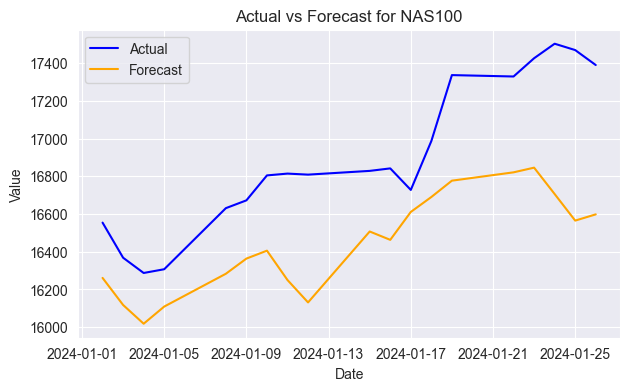

Unique ID: US500 - MAPE: 0.008226389846802204, R2 Score: 0.5084414052999069


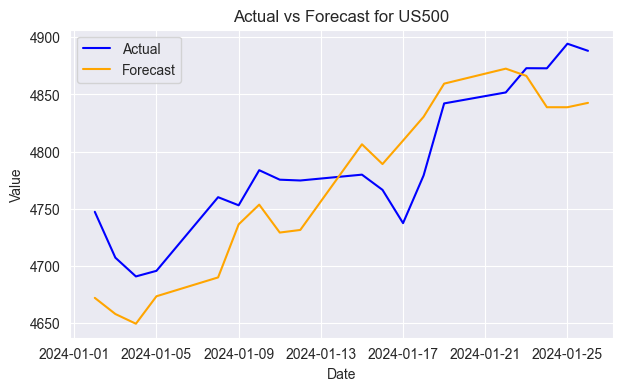

In [28]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

unique_ids = df_test['unique_id'].unique()

for unique_id in unique_ids:
    
    df_unique = df_test[df_test['unique_id'] == unique_id].copy()
    
    mape = mean_absolute_percentage_error(df_unique['y'], df_unique['NBEATS'])
    r2_score_ = r2_score(df_unique['y'], df_unique['NBEATS'])
    
    
    print(f"Unique ID: {unique_id} - MAPE: {mape}, R2 Score: {r2_score_}")
    
    
    plt.figure(figsize=(7, 4))
    plt.plot(df_unique['ds'], df_unique['y'], label='Actual', color='blue')
    plt.plot(df_unique['ds'], df_unique['NBEATS'], label='Forecast', color='orange')
    plt.title(f'Actual vs Forecast for {unique_id}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()